In [2]:
# 6.1 Import Library dan Konfigurasi Path
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Path folder evaluasi (sesuai hasil diagnostik)
EVAL_DIR = '../../no_stemming/outputs/evaluation'

# Validasi folder
if not os.path.exists(EVAL_DIR):
    raise FileNotFoundError(f"Folder {EVAL_DIR} tidak ditemukan. Periksa lokasi notebook.")

# Ambil semua file CSV evaluasi (kecuali ground_truth)
csv_files = [f for f in os.listdir(EVAL_DIR) 
             if f.startswith('evaluation_metrics_') and f.endswith('.csv')]
csv_files.sort()

if len(csv_files) < 7:
    print(f"Peringatan: Hanya ditemukan {len(csv_files)} file evaluasi. Pastikan ke-7 skenario sudah dijalankan.")
else:
    print(f"Berhasil ditemukan {len(csv_files)} file evaluasi.")

Berhasil ditemukan 7 file evaluasi.


In [3]:
# 6.2 Load, Gabungkan, dan Urutkan Sesuai Urutan Logis Penelitian
dfs = []
for filename in csv_files:
    filepath = os.path.join(EVAL_DIR, filename)
    df = pd.read_csv(filepath)
    
    # Kita ambil kolom yang sudah pasti ada di file CSV hasil evaluasi sebelumnya
    # Jika ada kolom Pearson-r kita masukkan juga untuk perbandingan korelasi
    cols_to_extract = ['Konfigurasi', 'Accuracy', 'Precision (M)', 'Recall (M)', 'F1-Score (M)']
    
    dfs.append(df[cols_to_extract])

# Gabungkan semua DataFrame
df_comparison = pd.concat(dfs, ignore_index=True)

# Pastikan tipe data numeric
metric_cols = ['Accuracy', 'Precision (M)', 'Recall (M)', 'F1-Score (M)']
df_comparison[metric_cols] = df_comparison[metric_cols].apply(pd.to_numeric)

# Urutan manual agar enak dibaca di Skripsi (dari InSet ke VTB)
custom_order = [
    'RSN + Ignore Function',
    'RSN + Remove Function',
    'RSN + Tanpa Ignore',
    'SLA + Ignore Function',
    'SLA + Remove Function',
    'SLA + Tanpa Ignore',
    'VTB (Translation Based)'
]

# Terapkan pengurutan
df_comparison['Konfigurasi'] = pd.Categorical(
    df_comparison['Konfigurasi'], 
    categories=custom_order, 
    ordered=True
)
df_comparison = df_comparison.sort_values('Konfigurasi').reset_index(drop=True)

print("\n TABEL PERBANDINGAN KINERJA SEMUA SKENARIO")
display(df_comparison)


 TABEL PERBANDINGAN KINERJA SEMUA SKENARIO


,Konfigurasi,Accuracy,Precision (M),Recall (M),F1-Score (M)
0,RSN + Ignore Function,0.4111,0.4074,0.3929,0.3553
1,RSN + Remove Function,0.3867,0.3677,0.3741,0.3640
2,RSN + Tanpa Ignore,0.3822,0.3635,0.3698,0.3602
3,SLA + Ignore Function,0.4467,0.4883,0.4627,0.3887
4,SLA + Remove Function,0.4244,0.4411,0.4429,0.3670
5,SLA + Tanpa Ignore,0.4467,0.4883,0.4627,0.3887
6,VTB (Translation Based),0.4356,0.4584,0.4441,0.4311


In [4]:
# 6.3 Simpan Hasil Perbandingan
COMPARE_CSV = os.path.join(EVAL_DIR, 'comparison_all_approaches.csv')
df_comparison.to_csv(COMPARE_CSV, index=False)
print(f"\nHasil perbandingan tersimpan di: {COMPARE_CSV}")


Hasil perbandingan tersimpan di: ../../no_stemming/outputs/evaluation\comparison_all_approaches.csv


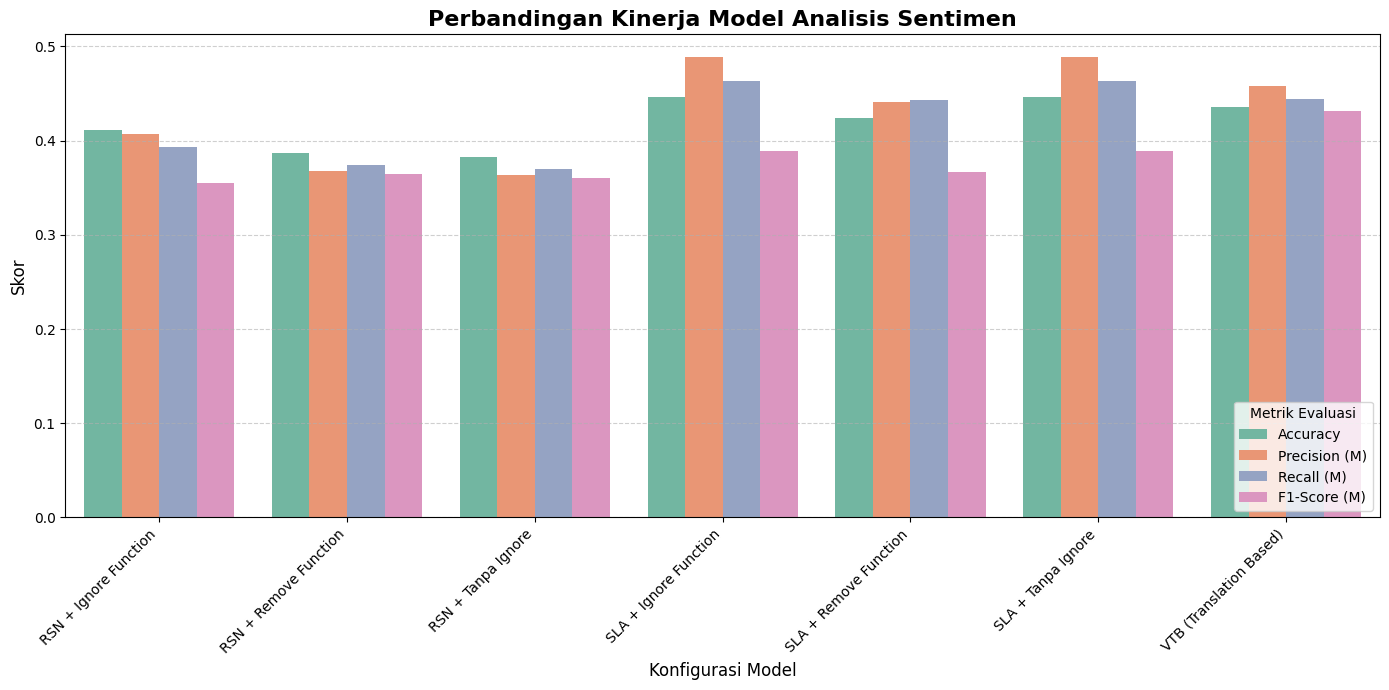


Grafik perbandingan tersimpan di: ../../no_stemming/outputs/evaluation\comparison_chart.png


In [5]:
# 6.4 Visualisasi Perbandingan
df_melt = df_comparison.melt(
    id_vars='Konfigurasi',
    value_vars=metric_cols,
    var_name='Metrik',
    value_name='Skor'
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_melt,
    x='Konfigurasi',
    y='Skor',
    hue='Metrik',
    palette='Set2',
    errorbar=None
)

plt.title('Perbandingan Kinerja Model Analisis Sentimen', fontsize=16, fontweight='bold')
plt.ylabel('Skor', fontsize=12)
plt.xlabel('Konfigurasi Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrik Evaluasi', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

chart_path = os.path.join(EVAL_DIR, 'comparison_chart.png')
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nGrafik perbandingan tersimpan di: {chart_path}")

In [6]:
# 5.5 Identifikasi Skenario Terbaik per Metrik
print("\nSKENARIO TERBAIK PER METRIK:")
for metric in metric_cols:
    best_idx = df_comparison[metric].idxmax()
    best_config = df_comparison.loc[best_idx, 'Konfigurasi']
    best_score = df_comparison.loc[best_idx, metric]
    print(f"  {metric:<25} -> {best_config} ({best_score:.4f})")


SKENARIO TERBAIK PER METRIK:
  Accuracy                  -> SLA + Ignore Function (0.4467)
  Precision (M)             -> SLA + Ignore Function (0.4883)
  Recall (M)                -> SLA + Ignore Function (0.4627)
  F1-Score (M)              -> VTB (Translation Based) (0.4311)
